# Store Sales Forecasting — Portfolio Case

## Бизнес-задача

**Цель:** спрогнозировать ежедневные продажи категории `BREAD/BAKERY` в магазине №1 на март 2016 года.

**Бизнес-ценность:**
- планирование закупок
- оптимизация складских запасов
- снижение списаний
- повышение доступности товара

**Тип задачи:** прогнозирование временных рядов  
**Целевая переменная:** `sales`  
**Период обучения:** 2013-01-01 — 2016-02-29  
**Период прогноза:** март 2016  

---

# 1. Загрузка и первичное изучение данных

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

DATA_PATH = '/kaggle/input/store-sales-time-series-forecasting/'

holidays_df = pd.read_csv(DATA_PATH + 'holidays_events.csv')
oil_df      = pd.read_csv(DATA_PATH + 'oil.csv')
sales_df    = pd.read_csv(DATA_PATH + 'train.csv')

sales_df['date'] = pd.to_datetime(sales_df['date'])

sales_df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [71]:
# Проверка наличия категории и временного диапазона
sales_df[sales_df['store_nbr'] == 1]['family'].unique()
sales_df[sales_df['store_nbr'] == 1]['date'].min(), sales_df[sales_df['store_nbr'] == 1]['date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

### Вывод
- Категория BREAD/BAKERY присутствует
- Данные доступны до конца февраля 2016
- Возможен прогноз на март 2016

---
# 2. EDA — анализ поведения продаж
Цель: выявить тренды, сезонность и стабильность продаж.

In [72]:
# фильтрация магазина и категории
mask = (
    (sales_df['store_nbr'] == 1) &
    (sales_df['family'] == 'BREAD/BAKERY') &
    (sales_df['date'] < '2016-04-01')
)

df = sales_df.loc[mask].copy()

# создаем полный календарь
full_dates = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
calendar_df = pd.DataFrame({'date': full_dates})

df = calendar_df.merge(df, on='date', how='left')

# заполняем пропуски
df['sales'] = df['sales'].fillna(0)
df['onpromotion'] = df['onpromotion'].fillna(0)

# агрегируем до уровня дня
df = df.groupby('date', as_index=False).agg({
    'sales': 'sum',
    'onpromotion': 'sum'
})

df.head()

,date,sales,onpromotion
0,2013-01-01,0.000,0.0
1,2013-01-02,470.652,0.0
2,2013-01-03,310.655,0.0
3,2013-01-04,198.366,0.0
4,2013-01-05,301.057,0.0


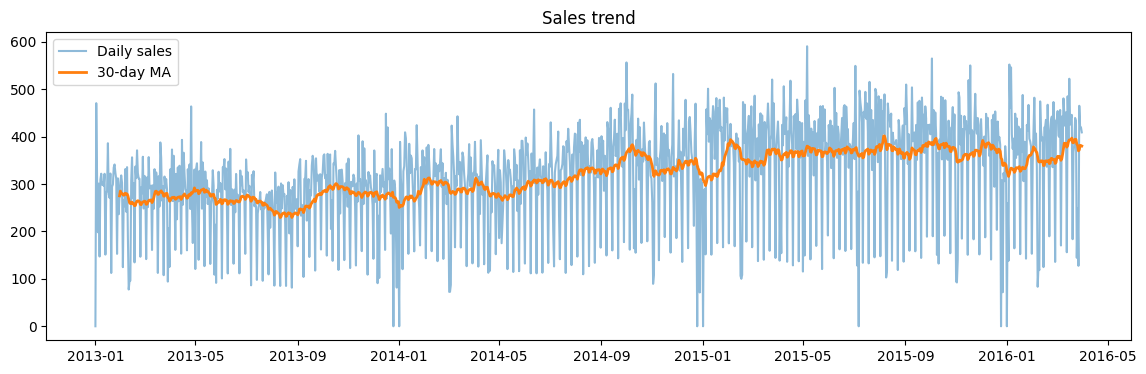

In [73]:
# Тренд продаж
rolling_30 = df['sales'].rolling(30).mean()

plt.figure(figsize=(14,4))
plt.plot(df['date'], df['sales'], alpha=0.5, label='Daily sales')
plt.plot(df['date'], rolling_30, linewidth=2, label='30-day MA')
plt.title('Sales trend')
plt.legend()
plt.show()

Вывод:
- продажи стабильны
- нулевых дней почти нет
- наблюдается умеренный рост

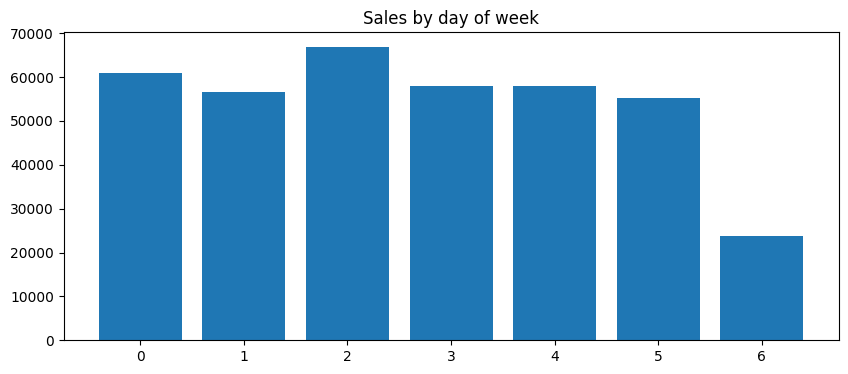

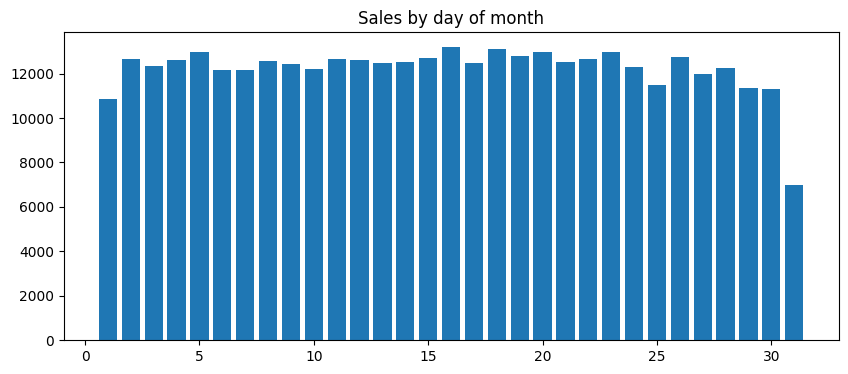

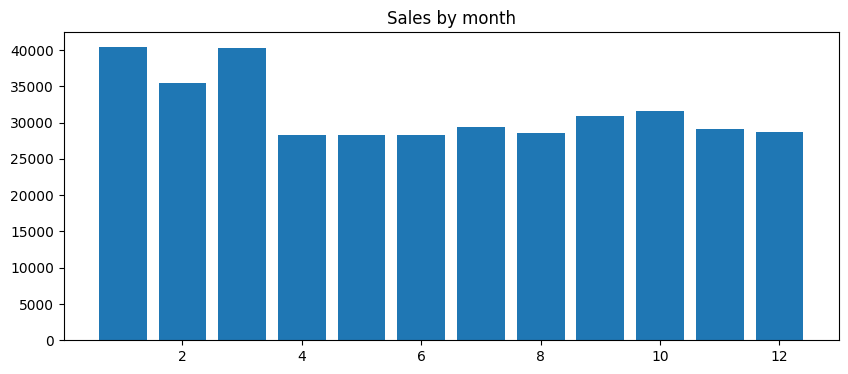

In [74]:
# Сезонность
# день недели
df['dow'] = df['date'].dt.dayofweek
dow_sales = df.groupby('dow')['sales'].sum()

plt.figure(figsize=(10,4))
plt.bar(dow_sales.index, dow_sales.values)
plt.title('Sales by day of week')
plt.show()

# день месяца
df['day'] = df['date'].dt.day
dom_sales = df.groupby('day')['sales'].sum()

plt.figure(figsize=(10,4))
plt.bar(dom_sales.index, dom_sales.values)
plt.title('Sales by day of month')
plt.show()

# месяц
df['month'] = df['date'].dt.month
month_sales = df.groupby('month')['sales'].sum()

plt.figure(figsize=(10,4))
plt.bar(month_sales.index, month_sales.values)
plt.title('Sales by month')
plt.show()

Выводы:
- воскресенье — самый слабый день
- в конце месяца продажи ниже
- в начале года спрос выше

---
# 3. Feature Engineering

In [75]:
# Защита от утечки данных
march_mask = df['date'] >= '2016-03-01'
sales_march_true = df.loc[march_mask, 'sales']

# скрываем реальные значения
df.loc[march_mask, 'sales'] = np.nan

# Календарные признаки
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['year'] = df['date'].dt.year

# Лаговые признаки
LAGS = [1, 7, 14, 28]

for lag in LAGS:
    df[f'sales_lag_{lag}'] = df['sales'].shift(lag)
    df[f'promo_lag_{lag}'] = df['onpromotion'].shift(lag)

# Скользящие статистики
WINDOWS = [7, 14, 28]

for w in WINDOWS:
    df[f'sales_mean_{w}'] = df['sales'].shift(1).rolling(w).mean()
    df[f'sales_std_{w}']  = df['sales'].shift(1).rolling(w).std()

# Праздники
holidays_df['date'] = pd.to_datetime(holidays_df['date'])
holidays_df = holidays_df.drop(columns=['locale_name', 'description', 'transferred'])

df = df.merge(holidays_df, on='date', how='left')

df['type'] = df['type'].fillna('Work Day')
df['locale'] = df['locale'].fillna('none')

# Цена нефти
oil_df['date'] = pd.to_datetime(oil_df['date'])
df = df.merge(oil_df, on='date', how='left')

df['dcoilwtico'] = df['dcoilwtico'].ffill()

# 4. Наивный прогноз (Baseline)

Наивный прогноз - в этом месяце продажи такие же как месяц назад. Проверим на продажах в феврале.

Naive RMSE: 188.52434382327357


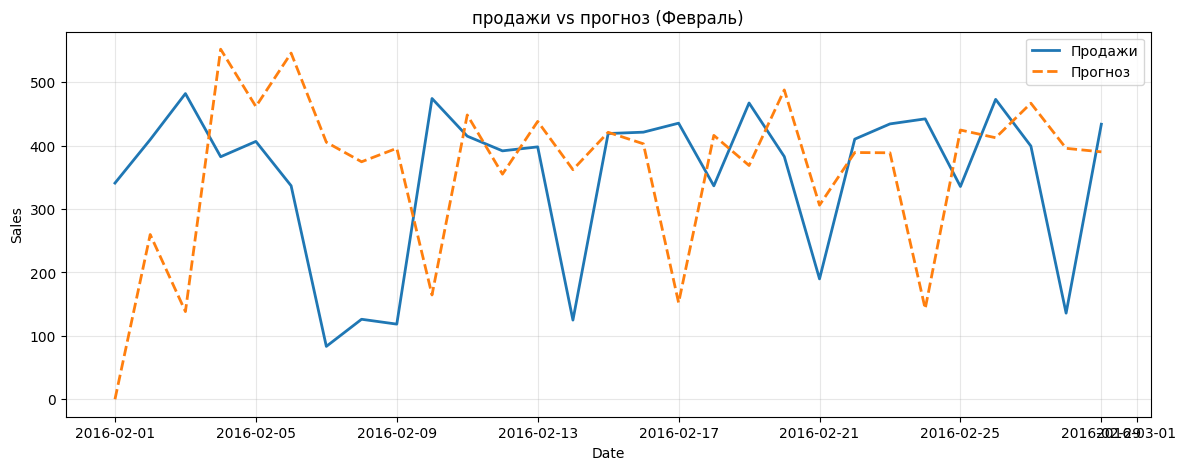

In [76]:
val_mask = (df['date'] >= '2016-02-01') & (df['date'] < '2016-03-01')

y_val = df.loc[val_mask, 'sales']
naive_pred = df['sales'].shift(31).loc[val_mask]

rmse_naive = np.sqrt(mean_squared_error(y_val, naive_pred))
print('Naive RMSE:', rmse_naive)

plt.figure(figsize=(14, 5))

plt.plot(df[val_mask]['date'], y_val, label='Продажи', linewidth=2)
plt.plot(df[val_mask]['date'], naive_pred, label=f'Прогноз', linestyle='--', linewidth=2)

plt.title(f'продажи vs прогноз (Февраль)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Наивная модель задаёт базовый уровень ошибки.

---
# 5. Обучение модели CatBoost

In [77]:
TARGET = 'sales'
DROP_COLS = ['date', TARGET]
FEATURES = [c for c in df.columns if c not in DROP_COLS]
CAT_FEATURES = ['type', 'locale']

val_start = '2016-02-01'
test_start = '2016-03-01'

train_df = df[df['date'] < val_start].dropna()
val_df   = df[(df['date'] >= val_start) & (df['date'] < test_start)].dropna()
test_df  = df[df['date'] >= test_start]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.02,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    early_stopping_rounds=500,
    verbose=False
)

model.fit(X_train, y_train, cat_features=CAT_FEATURES)

CatBoost RMSE: 37.59190068294242


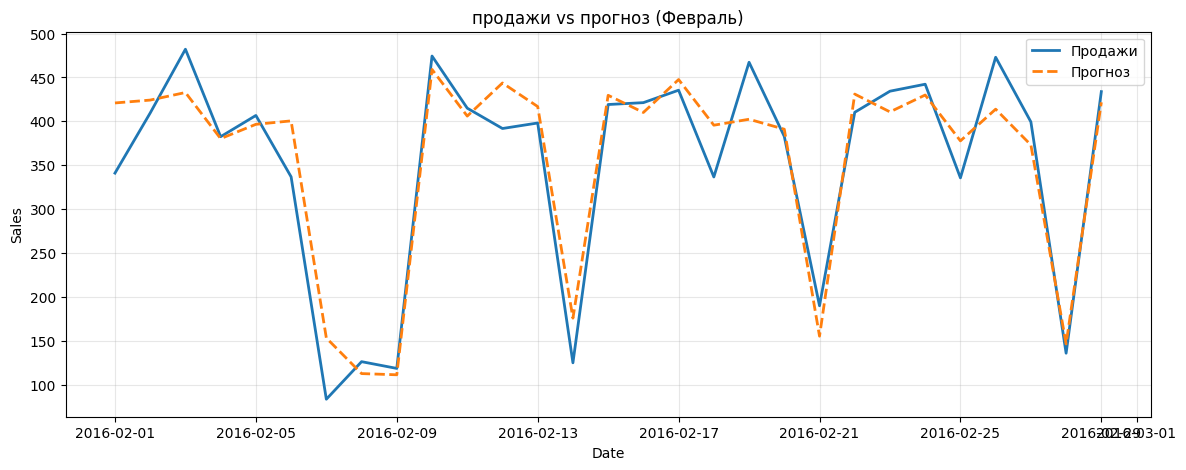

In [78]:
# Валидация
val_pred = model.predict(X_val)
rmse_model = np.sqrt(mean_squared_error(y_val, val_pred))

print('CatBoost RMSE:', rmse_model)

plt.figure(figsize=(14, 5))

plt.plot(val_df['date'], y_val, label='Продажи', linewidth=2)
plt.plot(val_df['date'], val_pred, label=f'Прогноз', linestyle='--', linewidth=2)

plt.title(f'продажи vs прогноз (Февраль)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Модель снижает ошибку примерно в 4 раза относительно baseline.

---
# 6. Финальное обучение и тест (март 2016)

Test RMSE (March): 76.84387666081592


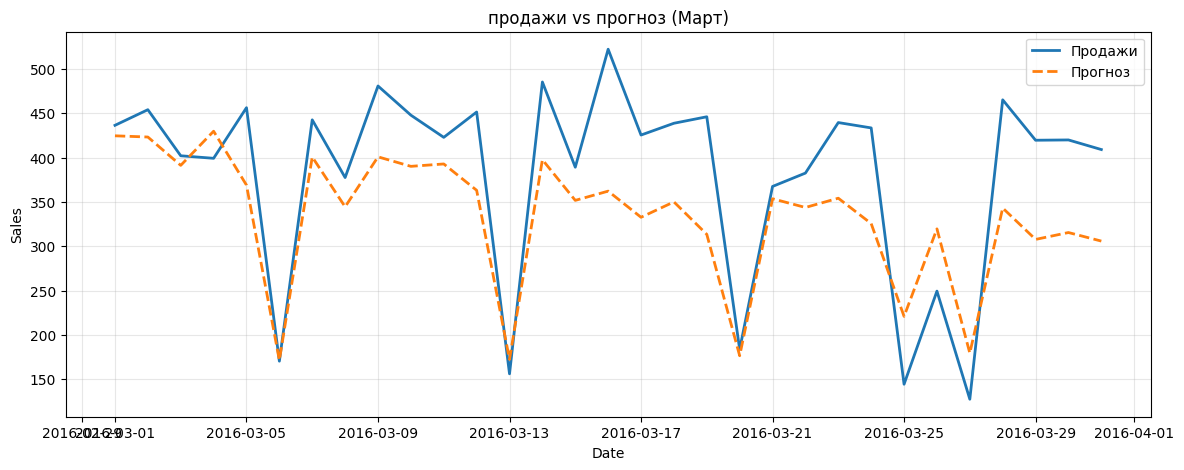

In [80]:
train_full = df[df['date'] < test_start].dropna()

X_train_full = train_full[FEATURES]
y_train_full = train_full[TARGET]

model.fit(X_train_full, y_train_full, cat_features=CAT_FEATURES)

test_pred = model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(sales_march_true, test_pred))

print('Test RMSE (March):', rmse_test)

plt.figure(figsize=(14, 5))

plt.plot(test_df['date'], sales_march_true, label='Продажи', linewidth=2)
plt.plot(test_df['date'], test_pred, label=f'Прогноз', linestyle='--', linewidth=2)

plt.title(f'продажи vs прогноз (Март)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Модель прогнозирует неплохо: улавливает тренды, но занижает пики.

---
# 7. Итоговые выводы

## Что удалось
- выявлена сезонность
- построен baseline
- обучена ML-модель
- ошибка снижена кратно

## Ограничения модели
- занижает пики спроса

## Возможные улучшения
- использовать SARIMAX / LightGBM
- расширить календарные признаки